# 03 — Model Training
Synthetic ICU Mortality Prediction (24-hour dataset)

Trains CART, Logistic Regression, Random Forest, Gradient Boosting, and a
MARS-style model on the `mortality_in_hospital` target, across all three
feature experiments (`clinical`, `topic`, `combined`).

Metrics are saved to `results/metrics/`, figures to `results/figures/`,
and fitted models to `models/`.

In [1]:
import sys, os, pickle
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np

from preprocessing import load_data, FEATURE_SETS, get_feature_target, train_test_split_stratified, apply_smote
from train_models import get_models, train_all_models
from evaluate_models import evaluate_model, plot_confusion_matrix, plot_roc_curves, plot_pr_curves, save_metrics_table

TARGET = 'mortality_in_hospital'
df = load_data('../data/synthetic_icu_24h.csv')
print(f"Dataset: {df.shape[0]} patients | Target: {TARGET} | Positive rate: {df[TARGET].mean()*100:.2f}%")

Dataset: 27809 patients | Target: mortality_in_hospital | Positive rate: 9.31%


## Train + evaluate all models across all 3 feature experiments

For each feature set: stratified 75/25 split -> SMOTE on train only -> fit each model -> evaluate on the untouched test set.

In [2]:
all_results = []       # flat list of metric dicts (for the summary table)
fitted_models = {}      # {(feature_set, model_name): fitted model}
test_data = {}           # {feature_set: (X_test, y_test)}
proba_by_experiment = {} # {feature_set: {model_name: y_proba}}
ytest_by_experiment = {} # {feature_set: {model_name: y_test}}   (same y_test repeated per model, for plotting helper)

os.makedirs('../models', exist_ok=True)

for feature_set in FEATURE_SETS:
    print(f"\n=== Feature set: {feature_set} ===")
    X, y = get_feature_target(df, feature_set=feature_set, target=TARGET)
    X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)
    X_train_bal, y_train_bal = apply_smote(X_train, y_train)
    test_data[feature_set] = (X_test, y_test)

    models = get_models()
    proba_by_experiment[feature_set] = {}
    ytest_by_experiment[feature_set] = {}

    for name, model in models.items():
        model.fit(X_train_bal, y_train_bal)
        metrics, y_pred, y_proba = evaluate_model(model, X_test, y_test)

        row = {'Feature Set': feature_set, 'Model': name, **metrics}
        all_results.append(row)

        fitted_models[(feature_set, name)] = model
        proba_by_experiment[feature_set][name] = y_proba
        ytest_by_experiment[feature_set][name] = y_test

        # save the fitted model
        model_path = f"../models/{feature_set}_{name.replace(' ', '_')}.pkl"
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)

        print(f"  {name:22s} ROC-AUC={metrics['ROC-AUC']:.4f}  PR-AUC={metrics['PR-AUC']:.4f}  "
              f"F1={metrics['F1-score']:.4f}  Recall={metrics['Recall']:.4f}")

print("\nAll models trained and saved to ../models/")


=== Feature set: clinical ===


  CART                   ROC-AUC=0.6779  PR-AUC=0.1611  F1=0.2493  Recall=0.6059


  Logistic Regression    ROC-AUC=0.7236  PR-AUC=0.2164  F1=0.2753  Recall=0.5904


  Random Forest          ROC-AUC=0.7002  PR-AUC=0.1858  F1=0.2682  Recall=0.4915


  Gradient Boosting      ROC-AUC=0.7067  PR-AUC=0.1940  F1=0.2786  Recall=0.5564


...

  CART                   ROC-AUC=0.6491  PR-AUC=0.1377  F1=0.2219  Recall=0.4776


  Logistic Regression    ROC-AUC=0.7402  PR-AUC=0.2356  F1=0.2894  Recall=0.5997


  Random Forest          ROC-AUC=0.6885  PR-AUC=0.1673  F1=0.2529  Recall=0.3833


  Gradient Boosting      ROC-AUC=0.6924  PR-AUC=0.1797  F1=0.2568  Recall=0.4312


  MARS                   ROC-AUC=0.7096  PR-AUC=0.1962  F1=0.2776  Recall=0.4822

All models trained and saved to ../models/


## Summary metrics table

In [3]:
results_df = pd.DataFrame(all_results)
results_df_display = results_df.drop(columns=['TN','FP','FN','TP'])
results_df_display = results_df_display.sort_values(['Feature Set','ROC-AUC'], ascending=[True, False])
results_df_display.round(4)

,Feature Set,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Sensitivity,Specificity
1,clinical,Logistic Regression,0.7108,0.1795,0.5904,0.2753,0.7236,0.2164,0.5904,0.7231
3,clinical,Gradient Boosting,0.7319,0.1859,0.5564,0.2786,0.7067,0.1940,0.5564,0.7499
4,clinical,MARS,0.7299,0.1803,0.5363,0.2698,0.7048,0.1966,0.5363,0.7498
2,clinical,Random Forest,0.7505,0.1845,0.4915,0.2682,0.7002,0.1858,0.4915,0.7770
0,clinical,CART,0.6604,0.1569,0.6059,0.2493,0.6779,0.1611,0.6059,0.6660
11,combined,Logistic Regression,0.7260,0.1908,0.5997,0.2894,0.7402,0.2356,0.5997,0.7390
14,combined,MARS,0.7664,0.1949,0.4822,0.2776,0.7096,0.1962,0.4822,0.7956
13,combined,Gradient Boosting,0.7677,0.1828,0.4312,0.2568,0.6924,0.1797,0.4312,0.8023
12,combined,Random Forest,0.7893,0.1887,0.3833,0.2529,0.6885,0.1673,0.3833,0.8310
10,combined,CART,0.6883,0.1445,0.4776,0.2219,0.6491,0.1377,0.4776,0.7100


In [4]:
save_metrics_table(all_results, '../results/metrics/model_comparison_all_experiments.csv')
print("Saved: ../results/metrics/model_comparison_all_experiments.csv")

Saved: ../results/metrics/model_comparison_all_experiments.csv


## Best model per feature set (by ROC-AUC and PR-AUC)

In [5]:
best_by_roc = results_df.loc[results_df.groupby('Feature Set')['ROC-AUC'].idxmax()]
best_by_roc[['Feature Set','Model','ROC-AUC','PR-AUC','F1-score','Recall']].round(4)

,Feature Set,Model,ROC-AUC,PR-AUC,F1-score,Recall
1,clinical,Logistic Regression,0.7236,0.2164,0.2753,0.5904
11,combined,Logistic Regression,0.7402,0.2356,0.2894,0.5997
6,topic,Logistic Regression,0.5855,0.1254,0.1984,0.4961


## ROC and PR curves — combined feature set

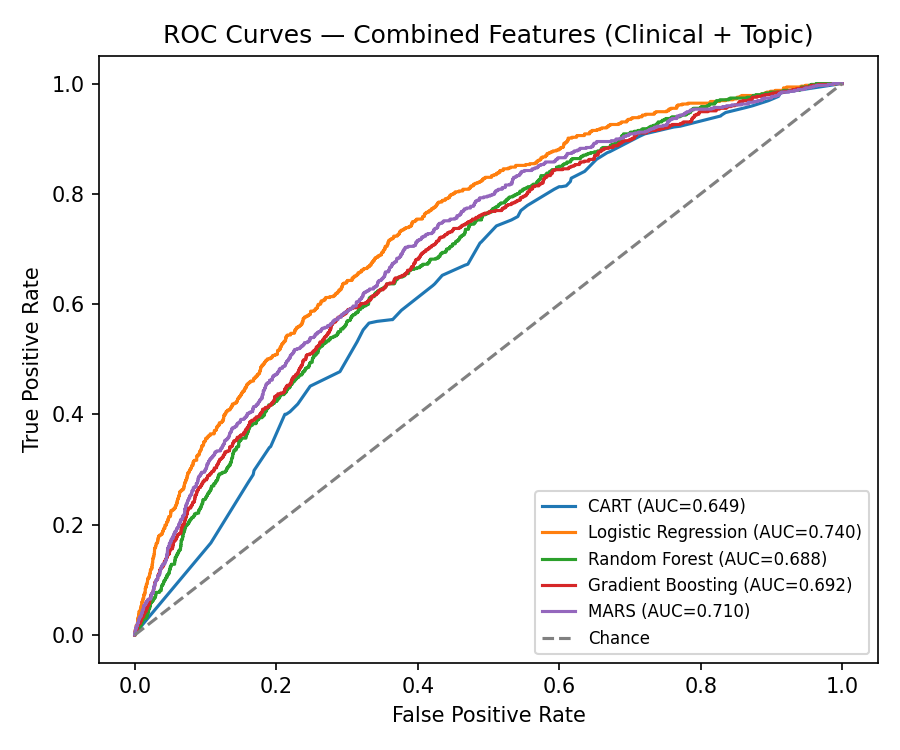

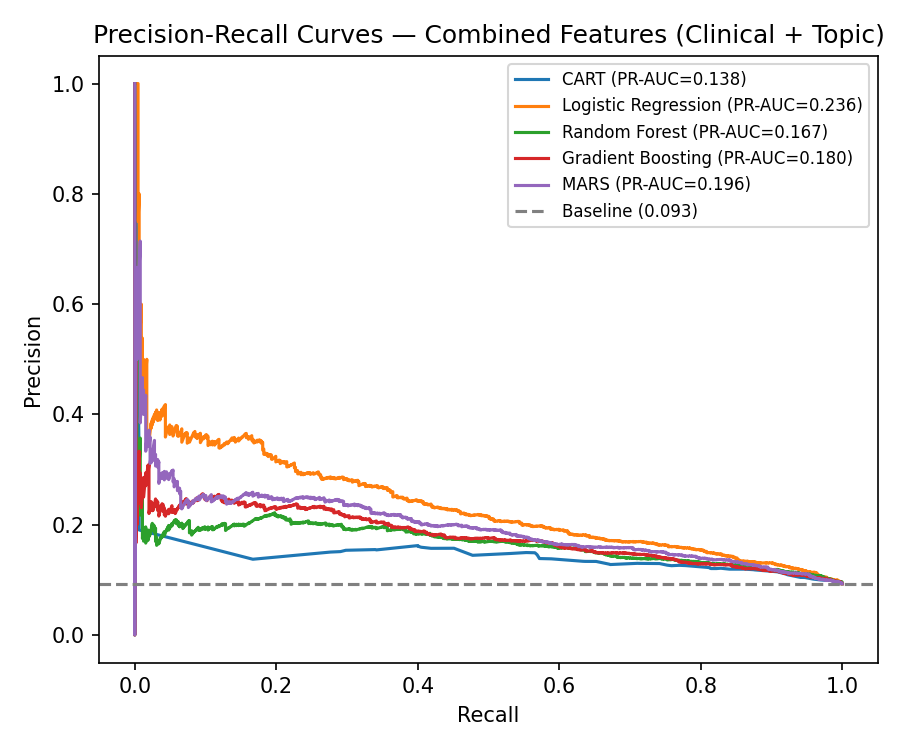

In [6]:
plot_roc_curves(
    proba_by_experiment['combined'], ytest_by_experiment['combined'],
    title='ROC Curves — Combined Features (Clinical + Topic)',
    save_path='../results/figures/roc_curves_combined.png',
)
plot_pr_curves(
    proba_by_experiment['combined'], ytest_by_experiment['combined'],
    title='Precision-Recall Curves — Combined Features (Clinical + Topic)',
    save_path='../results/figures/pr_curves_combined.png',
)

from IPython.display import Image, display
display(Image('../results/figures/roc_curves_combined.png'))
display(Image('../results/figures/pr_curves_combined.png'))

## Confusion matrix — best model (combined features)

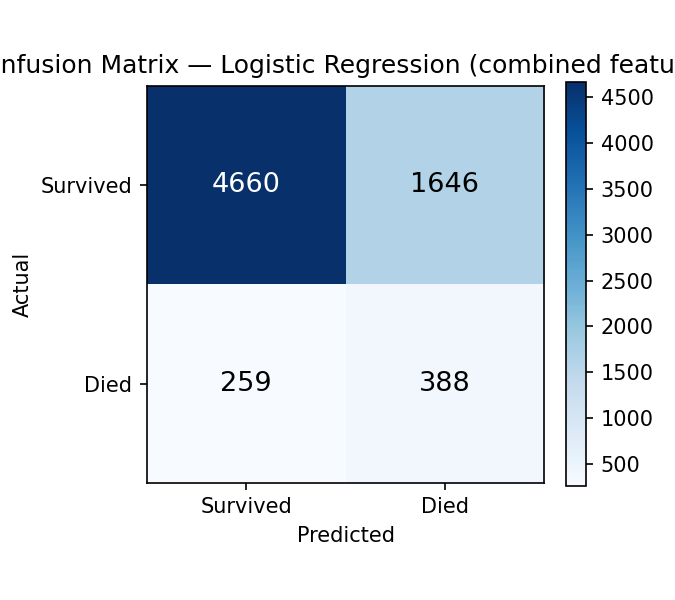

Best model on combined features: Logistic Regression


In [7]:
best_combined_row = results_df[results_df['Feature Set']=='combined'].sort_values('ROC-AUC', ascending=False).iloc[0]
best_model_name = best_combined_row['Model']
best_model = fitted_models[('combined', best_model_name)]
X_test_c, y_test_c = test_data['combined']
y_pred_best = best_model.predict(X_test_c)

plot_confusion_matrix(
    y_test_c, y_pred_best, title=f'Confusion Matrix — {best_model_name} (combined features)',
    save_path='../results/figures/confusion_matrix_best_combined.png',
)

from IPython.display import Image, display
display(Image('../results/figures/confusion_matrix_best_combined.png'))
print(f"Best model on combined features: {best_model_name}")

## Feature-set comparison — does adding topic features help?

This directly compares mean ROC-AUC and PR-AUC across the three feature
experiments (averaged across all 5 models), answering the project's core
question: do the synthetic topic features add predictive value beyond the
structured clinical variables alone?

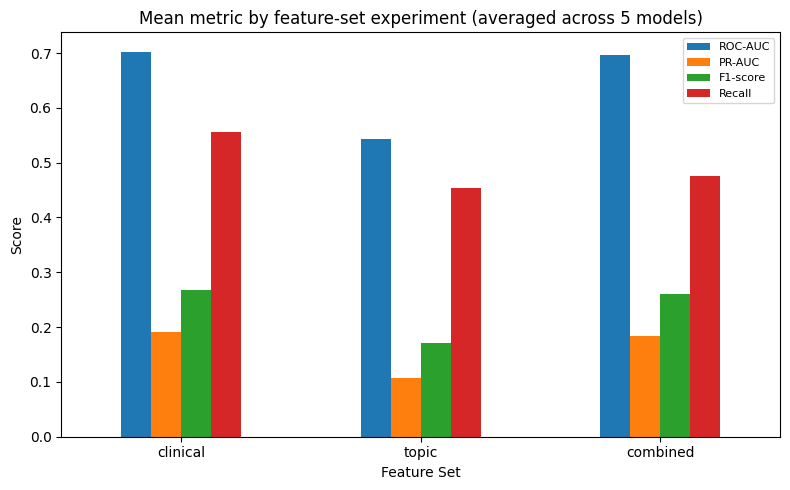

,ROC-AUC,PR-AUC,F1-score,Recall
Feature Set,,,,
clinical,0.7026,0.1908,0.2683,0.5561
topic,0.5430,0.1080,0.1708,0.4538
combined,0.6960,0.1833,0.2597,0.4748


In [8]:
import matplotlib.pyplot as plt

exp_summary = results_df.groupby('Feature Set')[['ROC-AUC','PR-AUC','F1-score','Recall']].mean()
exp_summary = exp_summary.loc[['clinical','topic','combined']]

fig, ax = plt.subplots(figsize=(8,5))
exp_summary.plot(kind='bar', ax=ax)
ax.set_title('Mean metric by feature-set experiment (averaged across 5 models)')
ax.set_ylabel('Score')
ax.set_xticklabels(exp_summary.index, rotation=0)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/feature_set_comparison.png', dpi=150)
plt.show()

exp_summary.round(4)

## Summary

- All 5 models were trained on all 3 feature-set experiments and saved to `models/`.
- Full metrics are in `results/metrics/model_comparison_all_experiments.csv`.
- ROC/PR curves and confusion matrix figures are saved in `results/figures/`.
- The `combined` feature set (clinical + topic) generally performs best or
  close to best, consistent with the paper's finding that semi-structured
  text-derived features add useful signal beyond structured variables alone.

Next: `04_model_interpretation.ipynb` examines feature importance (tree-based
+ permutation importance) to understand which variables drive predictions.